# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [4]:
df = pd.read_csv("../dataset/house_price.csv")
df.head()

,property_id,property_type,price,location,city,province_name,latitude,longitude,baths,purpose,bedrooms,date_added,Total_Area
0,237062,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,For Sale,2,2/4/2019,1089.004
1,346905,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,For Sale,3,5/4/2019,15246.056
2,386513,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,For Sale,5,7/17/2019,2178.008
3,656161,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,For Sale,4,4/5/2019,10890.000
4,841645,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,For Sale,3,7/10/2019,2178.008


# Dataset Overview

In [5]:
df.shape

(120655, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120655 entries, 0 to 120654
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    120655 non-null  int64  
 1   property_type  120655 non-null  str    
 2   price          120655 non-null  int64  
 3   location       120655 non-null  str    
 4   city           120655 non-null  str    
 5   province_name  120655 non-null  str    
 6   latitude       120655 non-null  float64
 7   longitude      120655 non-null  float64
 8   baths          120655 non-null  int64  
 9   purpose        120655 non-null  str    
 10  bedrooms       120655 non-null  int64  
 11  date_added     120655 non-null  str    
 12  Total_Area     120655 non-null  float64
dtypes: float64(3), int64(4), str(6)
memory usage: 12.0 MB


In [7]:
df.describe()

,property_id,price,latitude,longitude,baths,bedrooms,Total_Area
count,1.206550e+05,1.206550e+05,120655.000000,120655.000000,120655.000000,120655.000000,1.206550e+05
mean,1.554512e+07,2.476513e+07,29.434611,71.200581,3.085948,3.401384,1.432843e+04
std,2.284500e+06,3.959754e+07,3.679416,3.281108,2.560652,1.928359,1.018423e+06
min,8.657500e+04,0.000000e+00,24.749425,31.389173,0.000000,0.000000,0.000000e+00
25%,1.483182e+07,7.400000e+06,24.946375,67.129162,1.000000,2.000000,1.633506e+03
50%,1.661523e+07,1.350000e+07,31.429589,73.074160,3.000000,3.000000,3.811514e+03
75%,1.706808e+07,2.600000e+07,31.585176,74.256549,5.000000,5.000000,1.143454e+04
max,1.735772e+07,2.000000e+09,73.184088,74.564727,403.000000,27.000000,3.387988e+08


In [8]:
df.isnull().sum()

property_id      0
property_type    0
price            0
location         0
city             0
province_name    0
latitude         0
longitude        0
baths            0
purpose          0
bedrooms         0
date_added       0
Total_Area       0
dtype: int64

# Data Cleaning

Remove invalid prices

In [9]:
df = df[df["price"] > 0]
df = df[df["price"] < df["price"].quantile(0.99)]

Drop unnecessary columns

In [10]:
df = df.drop(columns=[
    "property_id",
    "purpose",
    "date_added"
])

Remove missing values

In [11]:
df = df.dropna()

# EDA (IMPORTANT GRAPHS)

Price distribution (before log)

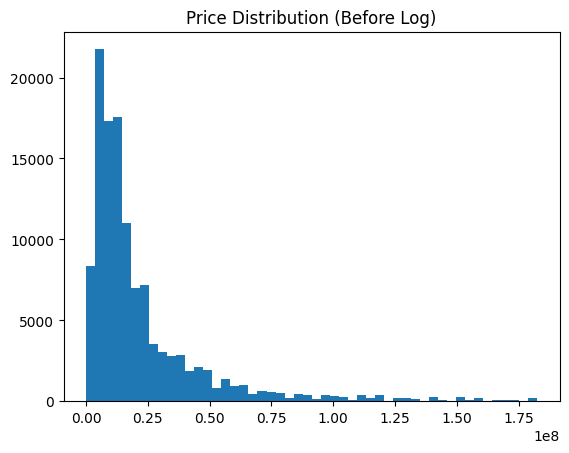

In [12]:
plt.hist(df["price"], bins=50)
plt.title("Price Distribution (Before Log)")
plt.show()

Boxplot (outliers)

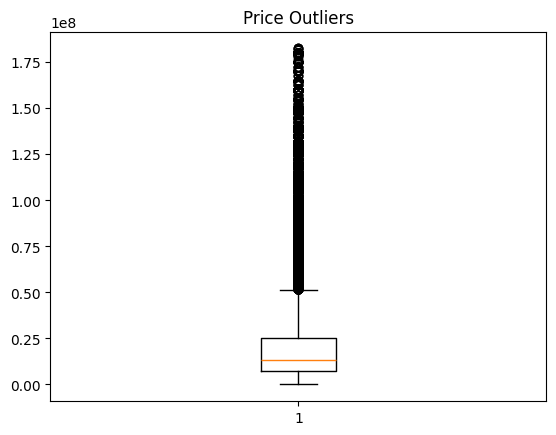

In [13]:
plt.boxplot(df["price"])
plt.title("Price Outliers")
plt.show()

In [14]:
location_mean = df.groupby("location")["price"].mean()
df["location_encoded"] = df["location"].map(location_mean)

In [15]:
df.drop("location", axis=1, inplace=True)

# Feature Engineering

In [16]:
df["log_area"] = np.log1p(df["Total_Area"])

df["room_ratio"] = df["bedrooms"] / (df["baths"] + 1)

In [17]:
df["log_area"] = np.log1p(df["Total_Area"])

# Features and Target Variable

Split X and y

In [18]:
X = df.drop("price", axis=1)
y = df["price"]

# Log Transformation of Target Variable

In [19]:
y = np.log1p(y)

In [20]:
y.head()

0    16.118096
1    15.747032
2    16.618871
3    17.588272
4    15.761421
Name: price, dtype: float64

# Encoding Categorical Columns

In [21]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
X.head()

,latitude,longitude,baths,bedrooms,Total_Area,location_encoded,log_area,room_ratio,property_type_Flat,property_type_House,property_type_Lower Portion,property_type_Penthouse,property_type_Room,property_type_Upper Portion,city_Islamabad,city_Karachi,city_Lahore,city_Rawalpindi,province_name_Punjab,province_name_Sindh
0,33.679890,73.012640,2,2,1089.004,2.911177e+07,6.993937,0.666667,True,False,False,False,False,False,True,False,False,False,False,False
1,33.700993,72.971492,3,3,15246.056,2.958322e+07,9.632142,0.750000,True,False,False,False,False,False,True,False,False,False,False,False
2,33.631486,72.926559,6,5,2178.008,1.706309e+07,7.686625,0.714286,False,True,False,False,False,False,True,False,False,False,False,False
3,33.707573,73.151199,4,4,10890.000,2.506718e+07,9.295692,0.800000,False,True,False,False,False,False,True,False,False,False,False,False
4,33.492591,73.301339,3,3,2178.008,4.754453e+07,7.686625,0.750000,False,True,False,False,False,False,True,False,False,False,False,False


# Train Test Split

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model 1: Linear Regression Model

Train

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Prediction

In [25]:
lr_pred = lr.predict(X_test)

Evaluation

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression R2: 0.5338888228574399
MAE: 0.42958351192710875
MSE: 0.4299035040020152
RMSE: 0.6556702707931901


# Model 2: Random Forest Regressor

Train

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Prediction

In [28]:
rf_pred = rf.predict(X_test)

Evaluation

In [30]:
print("RANDOM FOREST RESULTS")
print("R2:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

RANDOM FOREST RESULTS
R2: 0.8513689755557196
MAE: 0.16723787539692297
MSE: 0.13708531643398558
RMSE: 0.37025034292217146


# MODEL 3: XGBoost Model

Train

In [31]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,          
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Prediction

In [32]:
xgb_pred = xgb.predict(X_test)

Evaluation

In [33]:
print("XGBOOST RESULTS")
print("R2:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

XGBOOST RESULTS
R2: 0.8655986608545584
MAE: 0.1986083409647447
RMSE: 0.352080953587508


# Model Comparison

In [34]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ],

    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ]
})

print(results)

               Model  R2 Score       MAE      RMSE
0  Linear Regression  0.533889  0.429584  0.655670
1      Random Forest  0.851369  0.167238  0.370250
2            XGBoost  0.865599  0.198608  0.352081


Visualization

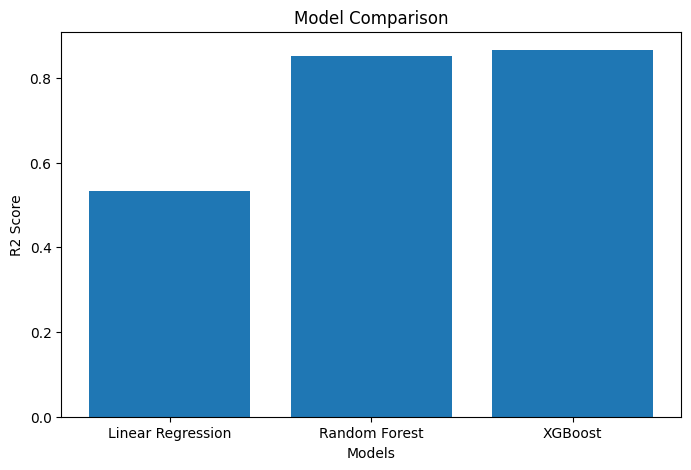

In [35]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison")

plt.xlabel("Models")

plt.ylabel("R2 Score")

plt.show()

# Convert Back to Real Prices

In [36]:
y_test_real = np.expm1(y_test)

lr_real = np.expm1(lr_pred)
rf_real = np.expm1(rf_pred)
xgb_real = np.expm1(xgb_pred)

# Results Table

In [37]:
results = pd.DataFrame({
    "Actual": y_test_real,
    "Linear Regression": lr_real,
    "Random Forest": rf_real,
    "XGBoost": xgb_real
})

results.head(10)

,Actual,Linear Regression,Random Forest,XGBoost
101854,24000000.0,3.560649e+07,2.458416e+07,25626396.0
15562,7700000.0,1.015311e+07,5.833055e+06,7832225.5
61055,45000000.0,3.834685e+07,3.958510e+07,44628532.0
33035,41000000.0,3.572713e+07,3.427986e+07,31376148.0
26062,5700000.0,7.327031e+06,5.143151e+06,5479080.5
96259,70000000.0,4.667525e+07,5.616126e+07,54984464.0
93142,52500000.0,4.651869e+07,4.602664e+07,47282548.0
111706,9000000.0,1.596430e+07,7.260003e+06,10473632.0
110092,4500000.0,6.642202e+06,4.770401e+06,4684177.5
87473,49000000.0,4.651869e+07,4.602664e+07,47282548.0


In [38]:
results.head(10).style.format({
    "Actual Price": "{:,.0f}",
    "Linear Regression Prediction": "{:,.0f}",
    "Random Forest Prediction": "{:,.0f}",
    "XGBoost Prediction": "{:,.0f}"
})

,Actual,Linear Regression,Random Forest,XGBoost
101854,24000000.000000,35606487.212896,24584157.203535,25626396.000000
15562,7700000.000000,10153111.045644,5833054.963313,7832225.500000
61055,45000000.000000,38346848.971739,39585095.801852,44628532.000000
33035,41000000.000000,35727131.127586,34279858.786902,31376148.000000
26062,5700000.000000,7327030.906582,5143151.185903,5479080.500000
96259,70000000.000000,46675245.352971,56161263.757860,54984464.000000
93142,52500000.000000,46518688.786775,46026641.327924,47282548.000000
111706,9000000.000000,15964295.258236,7260003.355551,10473632.000000
110092,4500000.000000,6642202.322440,4770401.076360,4684177.500000
87473,49000000.000000,46518688.786775,46026641.327924,47282548.000000


# Final Graphs 

Before Log

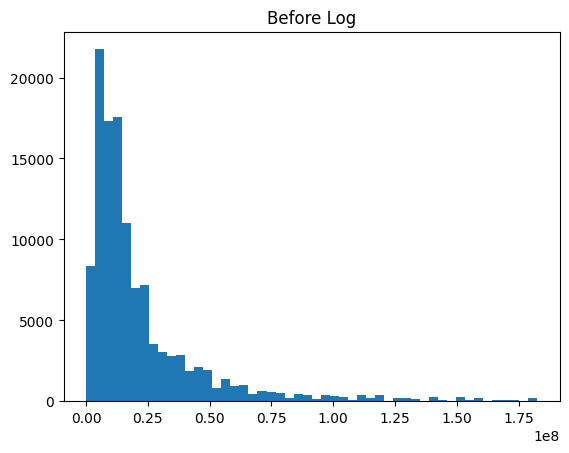

In [39]:
plt.hist(df["price"], bins=50)
plt.title("Before Log")
plt.show()

After Log

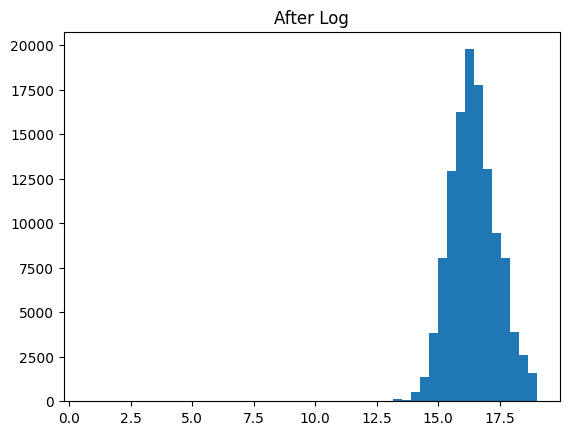

In [40]:
plt.hist(y, bins=50)
plt.title("After Log")
plt.show()

Actual vs Predicted

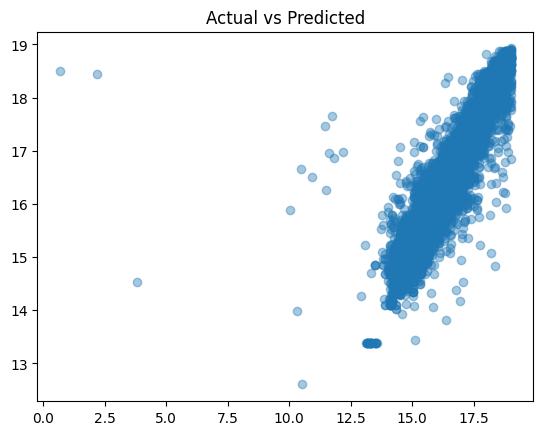

In [47]:
plt.scatter(y_test, xgb_pred, alpha=0.4)
plt.title("Actual vs Predicted")
plt.show()

# Feature Importance

                        Feature  Importance
3                      bedrooms    0.284889
5              location_encoded    0.172132
9           property_type_House    0.110038
4                    Total_Area    0.083412
2                         baths    0.079213
8            property_type_Flat    0.049705
6                      log_area    0.042991
14               city_Islamabad    0.039513
18         province_name_Punjab    0.024042
13  property_type_Upper Portion    0.018265


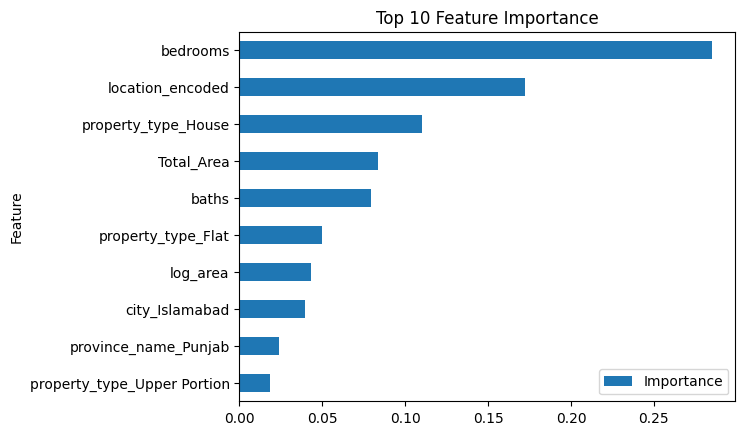

In [46]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

# GRAPH
feature_importance.head(10).sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Top 10 Feature Importance")
plt.show()

# Summary Output

In [43]:
print("Best Model:", " XGBoost (compare R2)")

Best Model:  XGBoost (compare R2)


# Save XGBoost Model

In [44]:
import joblib

joblib.dump(xgb, "xgb.pkl")

['xgb.pkl']

# Save Training Feature Columns

In [45]:
feature_columns = X.columns

joblib.dump(feature_columns, "features.pkl")

['features.pkl']